In [1]:
# importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\rpran\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: >

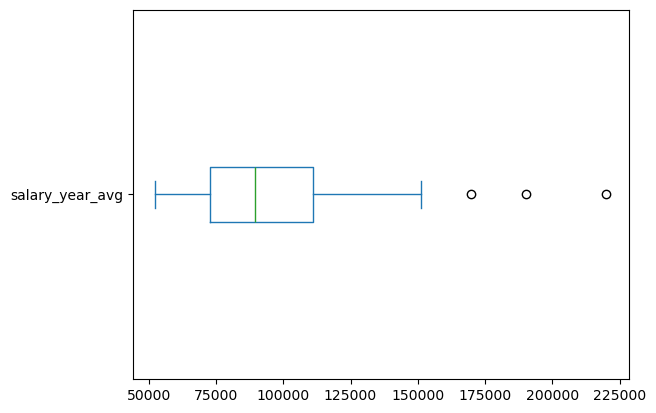

In [6]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'United States')]

df_DA_US = df_DA_US.dropna(subset='salary_year_avg')

df_DA_US['salary_year_avg'].plot(kind='box', vert=False)

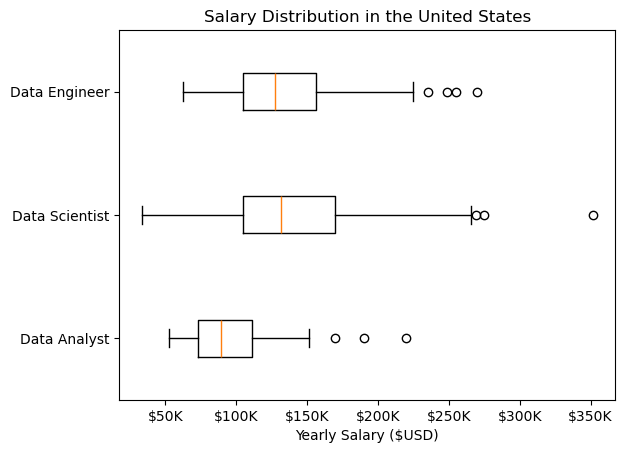

In [16]:
job_titles = ['Data Analyst','Data Scientist','Data Engineer']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_location'] == 'United States')].copy()
df_US = df_US.dropna(subset='salary_year_avg')

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, tick_labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.show()

In [21]:
df[(df['job_title_short'] == 'Data Analyst') & (df['salary_year_avg'].notna())]['salary_year_avg']

109        89000.0
180        90250.0
410       133285.0
988        62623.0
1413       71300.0
            ...   
784033    111175.0
784423     80850.0
784882     87500.0
785187    111175.0
785515    105000.0
Name: salary_year_avg, Length: 5451, dtype: float64